# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Isi Nama Kalian | Isi NRP Kalian|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [17]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uciml/mushroom-classification/mushrooms.csv


In [18]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
df= pd.read_csv("/kaggle/input/datasets/uciml/mushroom-classification/mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [19]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [20]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8119    False
8120    False
8121    False
8122    False
8123    False
Length: 8124, dtype: bool

#### Pengecekan Missing Value dan Data Duplikat

Berdasarkan hasil pemeriksaan dataset, tidak ditemukan adanya **missing value** (`null`/`NaN`) maupun **data duplikat**.

- Jumlah data: **8.124 baris**
- Jumlah kolom: **23 kolom**
- Missing value: **Tidak ada**
- Data duplikat: **Tidak ada**


In [21]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
print("Daftar nilai unik perfitur:")
for col in df.columns:
    print()
    print(f"{col}: {df[col].nunique()}")
    print(f"  {df[col].unique()}")

Daftar nilai unik perfitur:

class: 2
  ['p' 'e']

cap-shape: 6
  ['x' 'b' 's' 'f' 'k' 'c']

cap-surface: 4
  ['s' 'y' 'f' 'g']

cap-color: 10
  ['n' 'y' 'w' 'g' 'e' 'p' 'b' 'u' 'c' 'r']

bruises: 2
  ['t' 'f']

odor: 9
  ['p' 'a' 'l' 'n' 'f' 'c' 'y' 's' 'm']

gill-attachment: 2
  ['f' 'a']

gill-spacing: 2
  ['c' 'w']

gill-size: 2
  ['n' 'b']

gill-color: 12
  ['k' 'n' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r' 'y' 'o']

stalk-shape: 2
  ['e' 't']

stalk-root: 5
  ['e' 'c' 'b' 'r' '?']

stalk-surface-above-ring: 4
  ['s' 'f' 'k' 'y']

stalk-surface-below-ring: 4
  ['s' 'f' 'y' 'k']

stalk-color-above-ring: 9
  ['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y']

stalk-color-below-ring: 9
  ['w' 'p' 'g' 'b' 'n' 'e' 'y' 'o' 'c']

veil-type: 1
  ['p']

veil-color: 4
  ['w' 'n' 'o' 'y']

ring-number: 3
  ['o' 't' 'n']

ring-type: 5
  ['p' 'e' 'l' 'f' 'n']

spore-print-color: 9
  ['k' 'n' 'u' 'h' 'w' 'r' 'o' 'y' 'b']

population: 6
  ['s' 'n' 'a' 'v' 'y' 'c']

habitat: 7
  ['u' 'g' 'm' 'd' 'p' 'w' 'l']


In [22]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
for col in df.columns:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())



===== class =====
class
e    4208
p    3916
Name: count, dtype: int64

===== cap-shape =====
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64

===== cap-surface =====
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64

===== cap-color =====
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64

===== bruises =====
bruises
f    4748
t    3376
Name: count, dtype: int64

===== odor =====
odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64

===== gill-attachment =====
gill-attachment
f    7914
a     210
Name: count, dtype: int64

===== gill-spacing =====
gill-spacing
c    6812
w    1312
Name: count, dtype: int64

===== gill-size =====
gill-size
b    5612
n    2512
Name: count, dtype: int64

===== gill-color =====
gill-color
b    1728
p    1492
w    1202
n    1048
g   

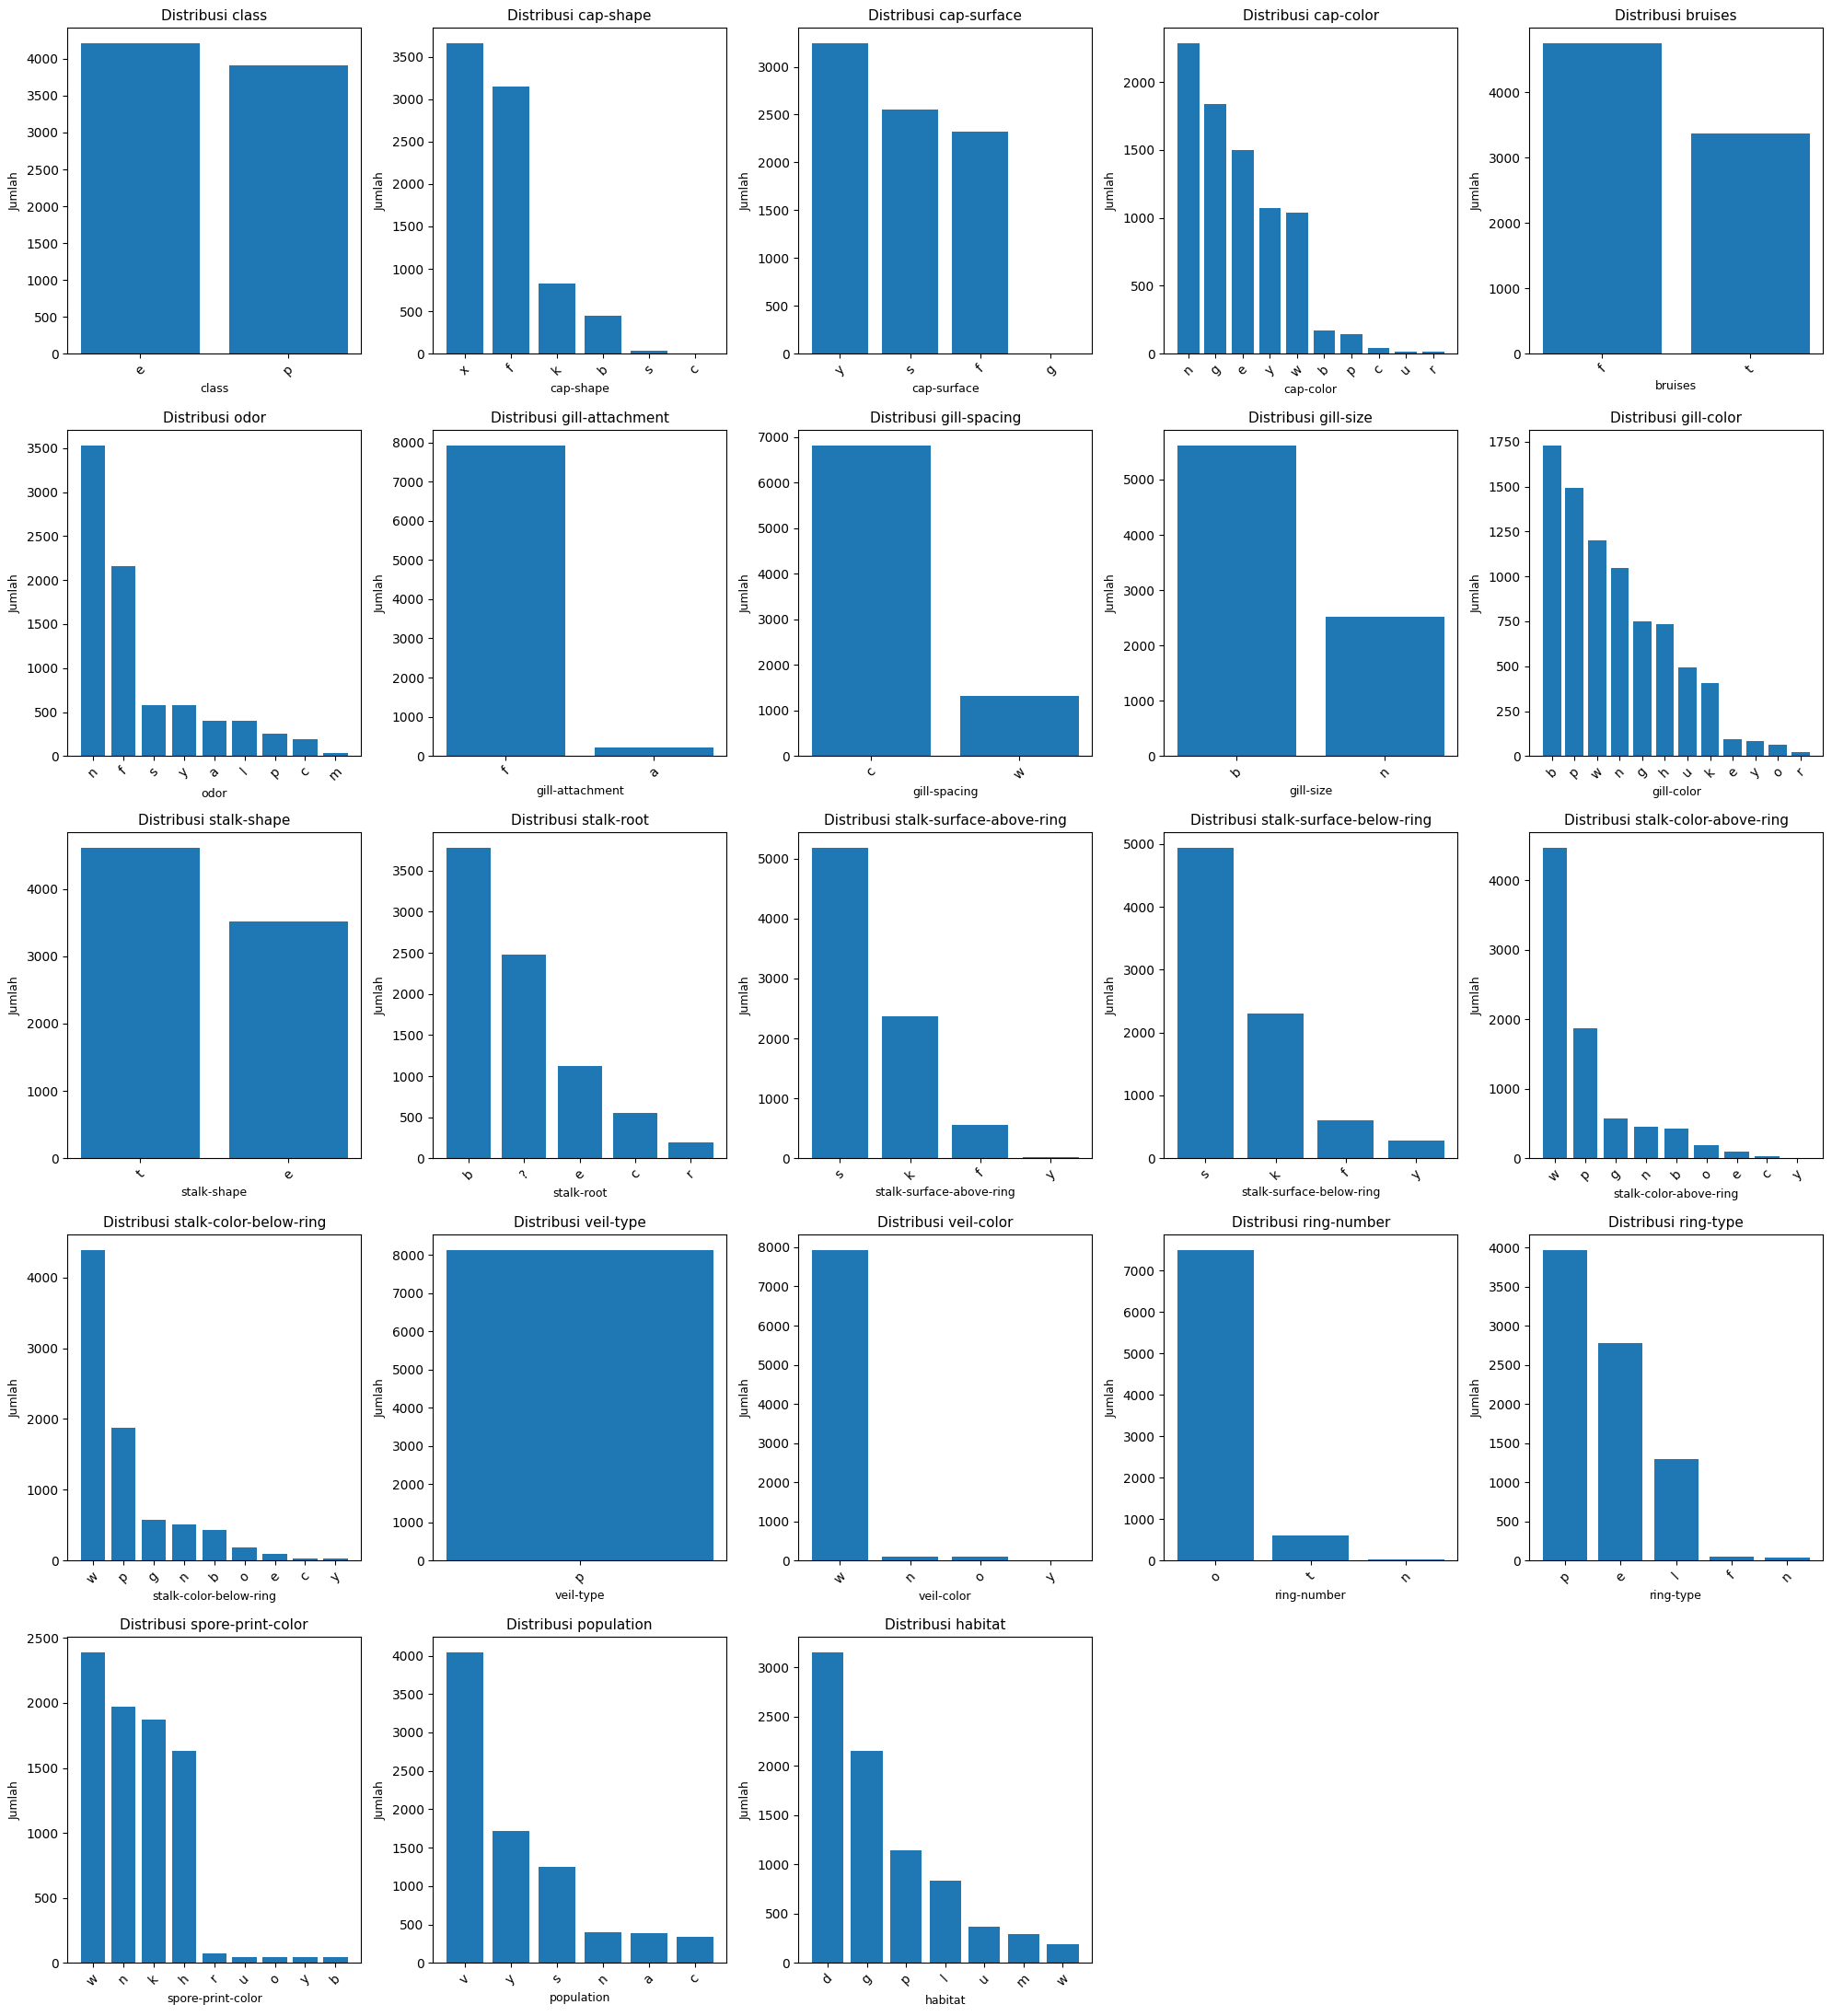

In [23]:
import matplotlib.pyplot as plt

# Ambil semua kolom kategorikal
categorical_cols = df.select_dtypes(include="object").columns

# Buat figure untuk 23 visualisasi
fig, axes = plt.subplots(5, 5, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Hitung jumlah tiap kategori
    counts = df[col].value_counts()

    # Buat bar chart
    axes[i].bar(counts.index.astype(str), counts.values)

    # Judul dan label
    axes[i].set_title(f"Distribusi {col}", fontsize=11)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel("Jumlah", fontsize=9)

    # Rotasi label jika kategori cukup banyak
    axes[i].tick_params(axis="x", rotation=45)

# Matikan subplot yang tidak terpakai
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


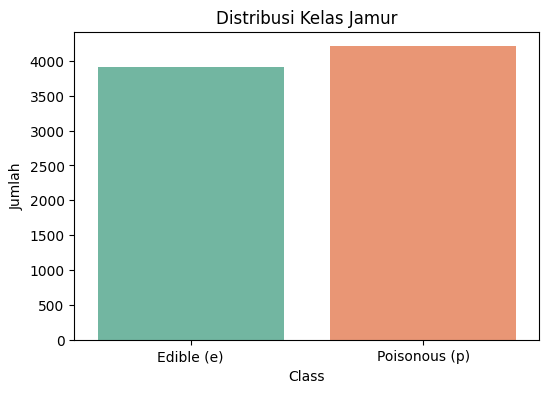

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', hue='class', palette=['#66c2a5', '#fc8d62'], legend=False)

plt.title('Distribusi Kelas Jamur')
plt.xlabel('Class')
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Edible (e)', 'Poisonous (p)'])
plt.show()


In [25]:
print("Edible (e)     :", (df['class'] == 'e').sum())
print("Poisonous (p)  :", (df['class'] == 'p').sum())

Edible (e)     : 4208
Poisonous (p)  : 3916


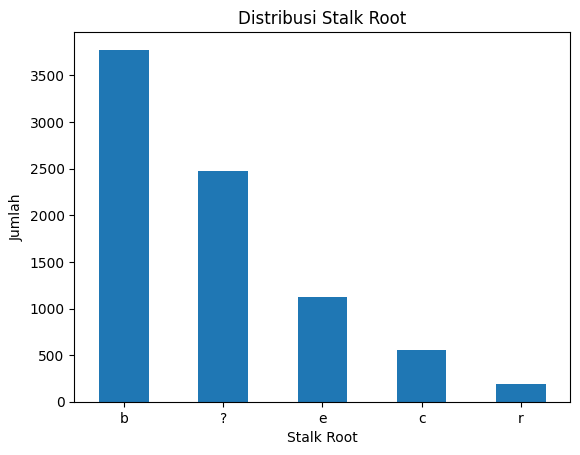

In [26]:
import matplotlib.pyplot as plt

df["stalk-root"].value_counts().plot(kind="bar")

plt.title("Distribusi Stalk Root")
plt.xlabel("Stalk Root")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

In [27]:
df['stalk-root'].value_counts()

stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64

In [28]:
df['stalk-root'].value_counts(normalize=True) * 100

stalk-root
b    46.479567
?    30.526834
e    13.786312
c     6.843919
r     2.363368
Name: proportion, dtype: float64

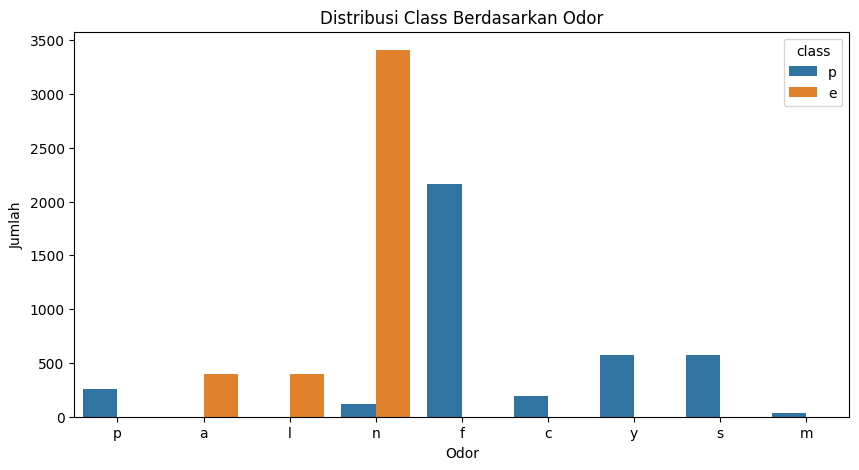

In [29]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='odor',
    hue='class'
)

plt.title('Distribusi Class Berdasarkan Odor')
plt.xlabel('Odor')
plt.ylabel('Jumlah')
plt.show()

In [30]:
pd.crosstab(df['odor'], df['class'], normalize='index') * 100

class,e,p
odor,,
a,100.000000,0.000000
c,0.000000,100.000000
f,0.000000,100.000000
l,100.000000,0.000000
m,0.000000,100.000000
n,96.598639,3.401361
p,0.000000,100.000000
s,0.000000,100.000000
y,0.000000,100.000000


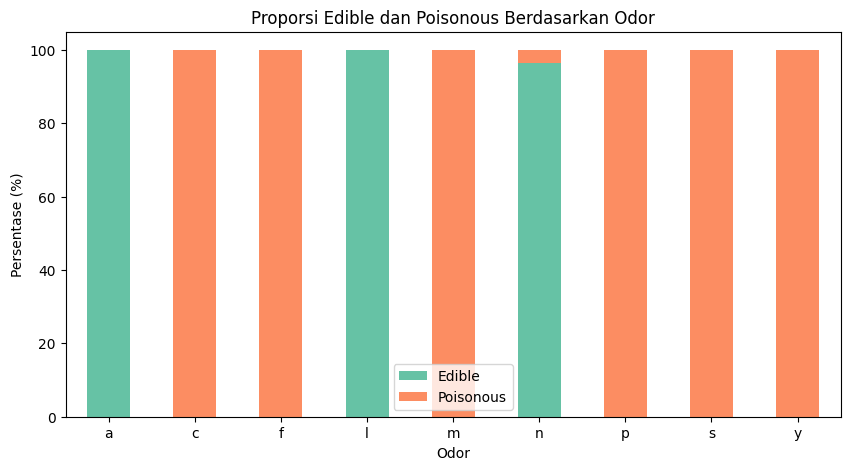

In [31]:
# Membuat tabel proporsi kelas berdasarkan odor
odor_class = pd.crosstab(
    df['odor'],
    df['class'],
    normalize='index'
) * 100

# Plot
odor_class.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    color=['#66c2a5', '#fc8d62']
)

plt.title('Proporsi Edible dan Poisonous Berdasarkan Odor')
plt.xlabel('Odor')
plt.ylabel('Persentase (%)')
plt.legend(['Edible', 'Poisonous'])
plt.xticks(rotation=0)
plt.show()



In [32]:
nunique = df.nunique().sort_values()

print(nunique)

veil-type                    1
class                        2
gill-attachment              2
gill-spacing                 2
stalk-shape                  2
gill-size                    2
bruises                      2
ring-number                  3
stalk-surface-above-ring     4
veil-color                   4
cap-surface                  4
stalk-surface-below-ring     4
ring-type                    5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      7
odor                         9
stalk-color-above-ring       9
stalk-color-below-ring       9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64


In [33]:
constant_features = nunique[nunique == 1]

print(constant_features)

veil-type    1
dtype: int64


In [34]:
#df = df.drop(columns=['veil-type'])


In [35]:
odor_class = pd.crosstab(
    df['odor'],
    df['class'],
    normalize='index'
) * 100

print(odor_class)

class           e           p
odor                         
a      100.000000    0.000000
c        0.000000  100.000000
f        0.000000  100.000000
l      100.000000    0.000000
m        0.000000  100.000000
n       96.598639    3.401361
p        0.000000  100.000000
s        0.000000  100.000000
y        0.000000  100.000000


In [36]:
for col in df.columns:
    min_count = df[col].value_counts().min()
    print(f"{col}: kategori terkecil = {min_count}")


class: kategori terkecil = 3916
cap-shape: kategori terkecil = 4
cap-surface: kategori terkecil = 4
cap-color: kategori terkecil = 16
bruises: kategori terkecil = 3376
odor: kategori terkecil = 36
gill-attachment: kategori terkecil = 210
gill-spacing: kategori terkecil = 1312
gill-size: kategori terkecil = 2512
gill-color: kategori terkecil = 24
stalk-shape: kategori terkecil = 3516
stalk-root: kategori terkecil = 192
stalk-surface-above-ring: kategori terkecil = 24
stalk-surface-below-ring: kategori terkecil = 284
stalk-color-above-ring: kategori terkecil = 8
stalk-color-below-ring: kategori terkecil = 24
veil-type: kategori terkecil = 8124
veil-color: kategori terkecil = 8
ring-number: kategori terkecil = 36
ring-type: kategori terkecil = 36
spore-print-color: kategori terkecil = 48
population: kategori terkecil = 340
habitat: kategori terkecil = 192


## Analisis Hasil EDA

Berdasarkan hasil eksplorasi data, dataset Mushroom terdiri dari **8.124 data dan 23 atribut**, dengan seluruh atribut bertipe kategorikal. Target `class` memiliki dua kategori, yaitu `e` (edible) sebanyak 4.208 data dan `p` (poisonous) sebanyak 3.916 data. Distribusi kedua kelas relatif seimbang, sehingga tidak terdapat masalah *class imbalance* yang signifikan.

Hasil pemeriksaan jumlah kategori menunjukkan bahwa sebagian besar atribut memiliki variasi kategori yang cukup baik. Namun, terdapat satu atribut yang tidak memiliki variasi, yaitu **`veil-type`**, yang hanya memiliki satu kategori `p` pada seluruh data. Karena atribut tersebut tidak memberikan informasi untuk membedakan kelas, `veil-type` dapat dihapus pada tahap preprocessing.

Pada atribut **`stalk-root`**, ditemukan nilai `?` sebanyak **2.480 data** atau sekitar **30,5%** dari keseluruhan dataset. Berdasarkan metadata dataset, simbol `?` menunjukkan nilai yang hilang atau tidak diketahui. Karena jumlahnya cukup besar, data tersebut tidak disarankan untuk dihapus. Nilai `?` akan diperlakukan sebagai kategori `unknown` pada tahap preprocessing.

Hasil analisis hubungan fitur dengan target menunjukkan bahwa atribut **`odor` merupakan salah satu fitur yang sangat informatif**. Beberapa kategori memiliki hubungan yang sangat kuat dengan kelas. Kategori `a` (almond) dan `l` (anise) seluruhnya termasuk edible, sedangkan kategori `c`, `f`, `m`, `p`, `s`, dan `y` seluruhnya termasuk poisonous. Sementara itu, kategori `n` (none) sebagian besar termasuk edible, yaitu sekitar **96,6%**.

Selain itu, ditemukan beberapa kategori dengan jumlah observasi yang sangat sedikit, seperti `cap-shape = c` yang hanya memiliki 4 data dan `stalk-color-above-ring = y` yang hanya memiliki 8 data. Meskipun frekuensinya rendah, kategori tersebut tetap dipertahankan karena masih merupakan informasi yang valid dan dapat digunakan oleh model.

## Kesimpulan EDA

Berdasarkan hasil EDA, dataset Mushroom memiliki karakteristik yang sesuai untuk digunakan dalam klasifikasi menggunakan metode **Naive Bayes**, karena seluruh fitur prediktor bersifat kategorikal dan target terdiri dari dua kelas yang relatif seimbang.

Beberapa keputusan preprocessing yang diperoleh dari EDA adalah:

- **`veil-type` dihapus** karena hanya memiliki satu kategori.
- Nilai **`?` pada `stalk-root` dipertahankan dan diubah menjadi `unknown`**, sehingga tidak kehilangan sekitar 30,5% data.
- Kategori dengan frekuensi rendah tetap dipertahankan.
- Target `class` akan dikonversi menjadi **0 = edible** dan **1 = poisonous**.
- Tidak diperlukan standardisasi atau normalisasi karena seluruh fitur bersifat kategorikal.
- **Correlation matrix tidak digunakan**, karena fitur-fitur pada dataset bersifat kategorikal dan analisis yang dilakukan lebih berfokus pada distribusi kategori serta hubungan atribut dengan target.
- Atribut **`odor` terlihat sangat berpengaruh terhadap kelas**, sehingga kemungkinan menjadi salah satu fitur penting dalam proses klasifikasi.


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

## Preprocessing untuk Categorical Naive Bayes

Categorical Naive Bayes digunakan karena seluruh fitur prediktor pada dataset Mushroom bersifat kategorikal.

Tahapan preprocessing yang dilakukan adalah:

1. Menghapus fitur `veil-type` karena hanya memiliki satu kategori sehingga tidak memberikan informasi tambahan bagi model.
2. Mengubah nilai `?` pada atribut `stalk-root` menjadi `unknown`. Nilai tersebut merepresentasikan data yang tidak diketahui dan dipertahankan agar tidak kehilangan 2.480 observasi.
3. Mengubah target `class` menjadi nilai biner:
   - `e` = 0 (edible)
   - `p` = 1 (poisonous)
4. Memisahkan fitur prediktor (`X`) dan target (`y`).
5. Membagi dataset menjadi data training dan testing dengan rasio 80:20 menggunakan `stratify` agar proporsi kelas tetap seimbang.
6. Menggunakan `OrdinalEncoder` untuk mengubah setiap kategori menjadi kode numerik.
7. Encoder hanya di-*fit* pada data training untuk menghindari data leakage.

In [37]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.


In [38]:
# Copy dataset
df_cat = df.copy()

# Hapus veil-type jika masih ada
df_cat = df_cat.drop(columns=['veil-type'], errors='ignore')

# Tangani missing value berbentuk '?'
df_cat['stalk-root'] = df_cat['stalk-root'].replace('?', 'unknown')

# Encode target hanya jika masih berupa e/p
if df_cat['class'].dtype == 'object':
    df_cat['class'] = df_cat['class'].map({
        'e': 0,
        'p': 1
    })

# Pisahkan X dan y
X = df_cat.drop(columns=['class'])
y = df_cat['class']

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nTarget:")
print(y.value_counts())


Shape X: (8124, 21)
Shape y: (8124,)

Target:
class
0    4208
1    3916
Name: count, dtype: int64


## Pembagian Data Training dan Testing

Dataset dibagi menjadi data training dan data testing dengan rasio 80:20. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi kemampuan model terhadap data yang belum pernah dilihat sebelumnya.

Parameter `stratify=y` digunakan untuk mempertahankan proporsi kelas edible dan poisonous pada data training dan testing. `random_state=42` digunakan agar pembagian data dapat direproduksi.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (6499, 21)
X_test : (1625, 21)
y_train: (6499,)
y_test : (1625,)


In [40]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

# Fit dan transform pada data training
X_train_encoded = encoder.fit_transform(X_train)

# Transform data testing
X_test_encoded = encoder.transform(X_test)

# Ubah menjadi integer
X_train_encoded = X_train_encoded.astype(int)
X_test_encoded = X_test_encoded.astype(int)

print("X_train encoded shape:", X_train_encoded.shape)
print("X_test encoded shape :", X_test_encoded.shape)


X_train encoded shape: (6499, 21)
X_test encoded shape : (1625, 21)


## Encoding Fitur Kategorikal

Categorical Naive Bayes membutuhkan fitur kategorikal dalam bentuk nilai integer yang merepresentasikan masing-masing kategori.

Oleh karena itu, digunakan `OrdinalEncoder`. Encoding dilakukan setelah pembagian data agar encoder hanya mempelajari kategori dari data training. Data testing kemudian ditransformasikan menggunakan encoder yang sama untuk menghindari data leakage.

Nilai `unknown` pada atribut `stalk-root` diperlakukan sebagai salah satu kategori.


In [41]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

# Fit dan transform pada data training
X_train_encoded = encoder.fit_transform(X_train)

# Transform data testing
X_test_encoded = encoder.transform(X_test)

# Ubah menjadi integer
X_train_encoded = X_train_encoded.astype(int)
X_test_encoded = X_test_encoded.astype(int)

print("X_train encoded shape:", X_train_encoded.shape)
print("X_test encoded shape :", X_test_encoded.shape)

X_train encoded shape: (6499, 21)
X_test encoded shape : (1625, 21)


In [42]:
stalk_root_index = X.columns.get_loc('stalk-root')

print("Kategori stalk-root:")
print(encoder.categories_[stalk_root_index])

Kategori stalk-root:
['b' 'c' 'e' 'r' 'unknown']


## Categorical Naive Bayes

Pada tahap ini digunakan `CategoricalNB` untuk melakukan klasifikasi jamur menjadi dua kelas, yaitu edible dan poisonous.

Model dilatih menggunakan data training yang telah melalui proses encoding. Parameter `alpha=1.0` digunakan sebagai Laplace smoothing untuk menghindari probabilitas nol pada kategori tertentu.


In [43]:
from sklearn.naive_bayes import CategoricalNB

cat_nb = CategoricalNB(alpha=1.0)

cat_nb.fit(X_train_encoded, y_train)

# Prediksi data testing
y_pred_cat = cat_nb.predict(X_test_encoded)


## Evaluasi Categorical Naive Bayes

Evaluasi model dilakukan menggunakan Accuracy, Precision, Recall, dan F1-Score.

Dalam eksperimen ini, kelas poisonous direpresentasikan sebagai `1`, sehingga Precision, Recall, dan F1-Score digunakan untuk melihat kemampuan model dalam mengenali jamur poisonous.

Recall menjadi metrik yang penting karena kesalahan berupa jamur poisonous yang diprediksi sebagai edible merupakan kesalahan yang berisiko dalam konteks klasifikasi jamur.


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy_cat = accuracy_score(y_test, y_pred_cat)
precision_cat = precision_score(y_test, y_pred_cat)
recall_cat = recall_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat)

print(f"Accuracy : {accuracy_cat:.4f}")
print(f"Precision: {precision_cat:.4f}")
print(f"Recall   : {recall_cat:.4f}")
print(f"F1-Score : {f1_cat:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_cat,
    target_names=['Edible', 'Poisonous']
))


Accuracy : 0.9458
Precision: 0.9901
Recall   : 0.8966
F1-Score : 0.9410

Classification Report:
              precision    recall  f1-score   support

      Edible       0.91      0.99      0.95       842
   Poisonous       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg       0.95      0.94      0.95      1625
weighted avg       0.95      0.95      0.95      1625



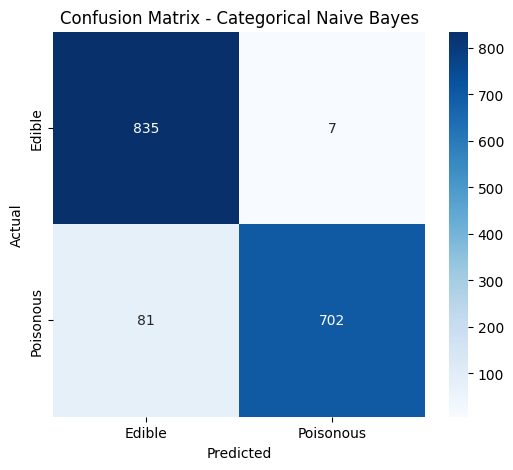

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_cat = confusion_matrix(y_test, y_pred_cat)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Edible', 'Poisonous'],
    yticklabels=['Edible', 'Poisonous']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Categorical Naive Bayes')

plt.show()

In [46]:
print(cm_cat)


[[835   7]
 [ 81 702]]


## Analisis Hasil Categorical Naive Bayes

Berdasarkan hasil evaluasi, model Categorical Naive Bayes memperoleh nilai **Accuracy sebesar 94,58%**, **Precision sebesar 99,01%**, **Recall sebesar 89,66%**, dan **F1-Score sebesar 94,10%**.

Nilai accuracy sebesar 94,58% menunjukkan bahwa model mampu mengklasifikasikan sebagian besar data jamur dengan benar. Precision untuk kelas poisonous mencapai 99%, yang menunjukkan bahwa ketika model memprediksi suatu jamur sebagai poisonous, prediksi tersebut hampir selalu benar.

Sementara itu, Recall untuk kelas poisonous sebesar 89,66%. Hal ini menunjukkan bahwa model berhasil mengenali sekitar 89,66% dari seluruh jamur poisonous pada data testing. Namun, masih terdapat sebagian jamur poisonous yang diprediksi sebagai edible. Kesalahan tersebut perlu mendapatkan perhatian karena dalam konteks klasifikasi jamur, poisonous yang diprediksi sebagai edible merupakan kesalahan yang lebih berisiko.

Berdasarkan classification report, performa model pada kelas edible memiliki precision sebesar 91% dan recall sebesar 99%, sedangkan kelas poisonous memiliki precision sebesar 99% dan recall sebesar 90%. Perbedaan ini menunjukkan bahwa model lebih baik dalam mengenali kelas edible dibandingkan dalam menangkap seluruh kasus poisonous.

Nilai F1-Score sebesar 94,10% menunjukkan bahwa model memiliki keseimbangan yang baik antara precision dan recall untuk kelas poisonous. Secara keseluruhan, CategoricalNB menunjukkan performa yang baik dalam melakukan klasifikasi pada Mushroom Dataset.

Hasil tersebut juga sejalan dengan temuan pada tahap EDA, terutama atribut `odor` yang memiliki hubungan sangat kuat dengan kelas target. Beberapa kategori `odor` bahkan memiliki distribusi kelas yang sempurna, sehingga fitur tersebut kemungkinan memberikan kontribusi besar terhadap performa klasifikasi.


## Analisis Confusion Matrix Categorical Naive Bayes

Berdasarkan confusion matrix, diperoleh hasil sebagai berikut:

| Actual | Predicted Edible | Predicted Poisonous |
|---|---:|---:|
| Edible | 835 | 7 |
| Poisonous | 81 | 702 |

Model berhasil mengklasifikasikan **835 dari 842 data edible** dengan benar dan **702 dari 783 data poisonous** dengan benar.

Terdapat **7 data edible** yang salah diklasifikasikan sebagai poisonous (*false positive*) dan **81 data poisonous** yang salah diklasifikasikan sebagai edible (*false negative*).

Kesalahan yang paling perlu diperhatikan adalah **81 data poisonous yang diprediksi sebagai edible**. Kesalahan ini menyebabkan model gagal mengenali sebagian jamur beracun sebagai jamur yang dapat dimakan. Hal tersebut tercermin dari nilai recall kelas poisonous sebesar **89,66%**.

Di sisi lain, hanya terdapat 7 data edible yang diprediksi sebagai poisonous. Hal ini menyebabkan precision kelas poisonous sangat tinggi, yaitu **99,01%**. Dengan kata lain, ketika model memprediksi sebuah jamur sebagai poisonous, kemungkinan prediksi tersebut benar sangat tinggi.

Secara keseluruhan, CategoricalNB menghasilkan performa yang baik dengan accuracy sebesar **94,58%** dan F1-Score sebesar **94,10%**. Namun, masih terdapat ruang untuk meningkatkan kemampuan model dalam mendeteksi seluruh jamur poisonous, khususnya dengan mengurangi jumlah false negative.


## Analisis Confusion Matrix Categorical Naive Bayes

Berdasarkan confusion matrix, diperoleh hasil sebagai berikut:

| Actual | Predicted Edible | Predicted Poisonous |
|---|---:|---:|
| Edible | 835 | 7 |
| Poisonous | 81 | 702 |

Model berhasil mengklasifikasikan **835 dari 842 data edible** dengan benar dan **702 dari 783 data poisonous** dengan benar.

Terdapat **7 data edible** yang salah diklasifikasikan sebagai poisonous (*false positive*) dan **81 data poisonous** yang salah diklasifikasikan sebagai edible (*false negative*).

Kesalahan yang paling perlu diperhatikan adalah **81 data poisonous yang diprediksi sebagai edible**. Kesalahan ini menyebabkan model gagal mengenali sebagian jamur beracun sebagai jamur yang dapat dimakan. Hal tersebut tercermin dari nilai recall kelas poisonous sebesar **89,66%**.

Di sisi lain, hanya terdapat 7 data edible yang diprediksi sebagai poisonous. Hal ini menyebabkan precision kelas poisonous sangat tinggi, yaitu **99,01%**. Dengan kata lain, ketika model memprediksi sebuah jamur sebagai poisonous, kemungkinan prediksi tersebut benar sangat tinggi.

Secara keseluruhan, CategoricalNB menghasilkan performa yang baik dengan accuracy sebesar **94,58%** dan F1-Score sebesar **94,10%**. Namun, masih terdapat ruang untuk meningkatkan kemampuan model dalam mendeteksi seluruh jamur poisonous, khususnya dengan mengurangi jumlah false negative.


## Preprocessing untuk Bernoulli Naive Bayes

Bernoulli Naive Bayes digunakan untuk data yang direpresentasikan dalam bentuk fitur biner, yaitu nilai `0` dan `1`.

Karena fitur pada Mushroom Dataset bersifat kategorikal, setiap kategori akan diubah menjadi fitur biner menggunakan **One-Hot Encoding**. Sebagai contoh, atribut `odor` akan menghasilkan beberapa kolom berdasarkan kategorinya, seperti `odor_a`, `odor_f`, `odor_n`, dan sebagainya.

Nilai `1` menunjukkan bahwa suatu observasi memiliki kategori tersebut, sedangkan nilai `0` menunjukkan bahwa observasi tidak memiliki kategori tersebut.

Fitur `veil-type` tetap tidak digunakan karena telah diidentifikasi sebagai fitur konstan pada tahap EDA. Nilai `unknown` pada `stalk-root` juga tetap dipertahankan sebagai salah satu kategori.

Train-test split yang sama digunakan seperti pada CategoricalNB agar perbandingan performa antar-model dilakukan pada data testing yang sama.


In [47]:
from sklearn.preprocessing import OneHotEncoder

encoder_bernoulli = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_bernoulli = encoder_bernoulli.fit_transform(X_train)
X_test_bernoulli = encoder_bernoulli.transform(X_test)

print("X_train shape:", X_train_bernoulli.shape)
print("X_test shape :", X_test_bernoulli.shape)


X_train shape: (6499, 116)
X_test shape : (1625, 116)


In [48]:
print(X_train_bernoulli.shape)
print(X_test_bernoulli.shape)

print("\n5 data pertama:")
print(X_train_bernoulli[:5])


(6499, 116)
(1625, 116)

5 data pertama:
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0.
  1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
  0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
  0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 0. 0. 0. 0. 0.

## Pemodelan Bernoulli Naive Bayes

Setelah seluruh fitur kategorikal diubah menjadi representasi biner menggunakan One-Hot Encoding, data digunakan untuk melatih model Bernoulli Naive Bayes.

BernoulliNB memodelkan kemunculan atau ketidakmunculan suatu fitur. Oleh karena itu, representasi One-Hot Encoding sesuai dengan karakteristik model ini.


In [49]:
from sklearn.naive_bayes import BernoulliNB

bernoulli_nb = BernoulliNB(alpha=1.0)

bernoulli_nb.fit(
    X_train_bernoulli,
    y_train
)

y_pred_bernoulli = bernoulli_nb.predict(X_test_bernoulli)


## Evaluasi Bernoulli Naive Bayes

Model Bernoulli Naive Bayes dievaluasi menggunakan Accuracy, Precision, Recall, dan F1-Score.

Karena kelas poisonous direpresentasikan sebagai `1`, Precision, Recall, dan F1-Score berfokus pada kemampuan model dalam mengenali kelas poisonous.

Selain metrik tersebut, confusion matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada masing-masing kelas.


In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy_bernoulli = accuracy_score(
    y_test,
    y_pred_bernoulli
)

precision_bernoulli = precision_score(
    y_test,
    y_pred_bernoulli
)

recall_bernoulli = recall_score(
    y_test,
    y_pred_bernoulli
)

f1_bernoulli = f1_score(
    y_test,
    y_pred_bernoulli
)

print(f"Accuracy : {accuracy_bernoulli:.4f}")
print(f"Precision: {precision_bernoulli:.4f}")
print(f"Recall   : {recall_bernoulli:.4f}")
print(f"F1-Score : {f1_bernoulli:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_bernoulli,
    target_names=['Edible', 'Poisonous']
))


Accuracy : 0.9329
Precision: 0.9814
Recall   : 0.8774
F1-Score : 0.9265

Classification Report:
              precision    recall  f1-score   support

      Edible       0.90      0.98      0.94       842
   Poisonous       0.98      0.88      0.93       783

    accuracy                           0.93      1625
   macro avg       0.94      0.93      0.93      1625
weighted avg       0.94      0.93      0.93      1625



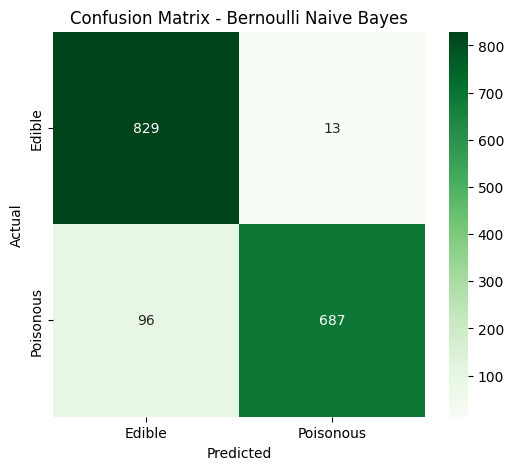

In [51]:
from sklearn.metrics import confusion_matrix

cm_bernoulli = confusion_matrix(
    y_test,
    y_pred_bernoulli
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_bernoulli,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Edible', 'Poisonous'],
    yticklabels=['Edible', 'Poisonous']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Bernoulli Naive Bayes')

plt.show()

## Analisis Hasil Bernoulli Naive Bayes

Berdasarkan hasil evaluasi, model Bernoulli Naive Bayes memperoleh **Accuracy sebesar 93,29%**, **Precision sebesar 98,14%**, **Recall sebesar 87,74%**, dan **F1-Score sebesar 92,65%**.

Accuracy sebesar 93,29% menunjukkan bahwa model mampu mengklasifikasikan sebagian besar data testing dengan benar. Precision kelas poisonous sebesar 98,14% menunjukkan bahwa sebagian besar jamur yang diprediksi sebagai poisonous memang merupakan jamur poisonous.

Namun, Recall kelas poisonous hanya mencapai 87,74%. Artinya, masih terdapat sebagian jamur poisonous yang tidak berhasil dikenali oleh model dan justru diprediksi sebagai edible. Hal ini menjadi perhatian karena false negative merupakan jenis kesalahan yang lebih berisiko dalam klasifikasi jamur.

Dibandingkan dengan CategoricalNB, performa BernoulliNB lebih rendah. CategoricalNB memperoleh Accuracy sebesar 94,58%, Precision sebesar 99,01%, Recall sebesar 89,66%, dan F1-Score sebesar 94,10%. Dengan demikian, BernoulliNB mengalami penurunan pada seluruh metrik utama.

Perbedaan performa tersebut dapat disebabkan oleh representasi fitur yang digunakan. Pada BernoulliNB, setiap kategori diubah menjadi fitur biner melalui One-Hot Encoding sehingga menghasilkan **116 fitur** dari 21 atribut awal. Representasi ini sesuai dengan karakteristik BernoulliNB, tetapi informasi kategorikal asli direpresentasikan sebagai kemunculan atau ketidakmunculan kategori.

Secara keseluruhan, BernoulliNB tetap memberikan performa yang baik, tetapi berdasarkan hasil sementara **CategoricalNB lebih unggul** pada dataset Mushroom.


## Multinomial Naive Bayes

Multinomial Naive Bayes umumnya digunakan pada data yang berupa jumlah atau frekuensi kemunculan suatu fitur. Pada eksperimen ini, fitur kategorikal telah diubah menggunakan One-Hot Encoding sehingga setiap kategori direpresentasikan sebagai nilai biner 0 atau 1.

Meskipun representasi ini lebih umum digunakan pada BernoulliNB, data hasil One-Hot Encoding juga dapat digunakan pada MultinomialNB karena seluruh nilainya bersifat non-negatif.

Untuk menjaga perbandingan yang adil, MultinomialNB menggunakan data training dan testing serta hasil One-Hot Encoding yang sama dengan BernoulliNB.


In [52]:
from sklearn.naive_bayes import MultinomialNB

multinomial_nb = MultinomialNB(alpha=1.0)

multinomial_nb.fit(
    X_train_bernoulli,
    y_train
)

# Prediksi data testing
y_pred_multinomial = multinomial_nb.predict(
    X_test_bernoulli
)

## Evaluasi Multinomial Naive Bayes

Model Multinomial Naive Bayes dievaluasi menggunakan Accuracy, Precision, Recall, dan F1-Score.

Selain metrik tersebut, confusion matrix digunakan untuk mengetahui jumlah prediksi yang benar dan kesalahan klasifikasi pada masing-masing kelas.

Khususnya, recall kelas poisonous diperhatikan karena kesalahan berupa jamur poisonous yang diprediksi sebagai edible merupakan false negative yang lebih berisiko.


In [53]:
accuracy_multinomial = accuracy_score(
    y_test,
    y_pred_multinomial
)

precision_multinomial = precision_score(
    y_test,
    y_pred_multinomial
)

recall_multinomial = recall_score(
    y_test,
    y_pred_multinomial
)

f1_multinomial = f1_score(
    y_test,
    y_pred_multinomial
)

print(f"Accuracy : {accuracy_multinomial:.4f}")
print(f"Precision: {precision_multinomial:.4f}")
print(f"Recall   : {recall_multinomial:.4f}")
print(f"F1-Score : {f1_multinomial:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_multinomial,
    target_names=['Edible', 'Poisonous']
))

Accuracy : 0.9458
Precision: 0.9901
Recall   : 0.8966
F1-Score : 0.9410

Classification Report:
              precision    recall  f1-score   support

      Edible       0.91      0.99      0.95       842
   Poisonous       0.99      0.90      0.94       783

    accuracy                           0.95      1625
   macro avg       0.95      0.94      0.95      1625
weighted avg       0.95      0.95      0.95      1625



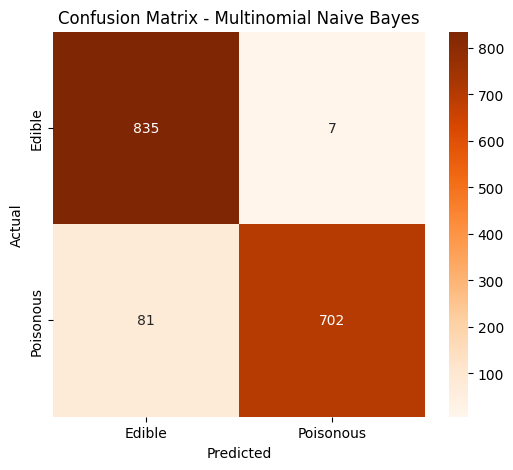

In [54]:
cm_multinomial = confusion_matrix(
    y_test,
    y_pred_multinomial
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_multinomial,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Edible', 'Poisonous'],
    yticklabels=['Edible', 'Poisonous']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Multinomial Naive Bayes')

plt.show()


In [55]:
print(cm_multinomial)

[[835   7]
 [ 81 702]]


### Mengapa MultinomialNB Dapat Digunakan?

Secara teori, **Multinomial Naive Bayes** lebih umum digunakan untuk data yang berupa **count atau frekuensi**, misalnya jumlah kemunculan kata pada klasifikasi teks.

Pada eksperimen ini, fitur kategorikal pada Mushroom Dataset diubah menggunakan **One-Hot Encoding**. Hasil encoding hanya memiliki nilai 0 dan 1 sehingga seluruh fitur bersifat non-negatif. Kondisi tersebut memungkinkan data digunakan sebagai input untuk MultinomialNB.

Sebagai contoh, suatu kategori pada fitur `odor` dapat diubah menjadi beberapa fitur biner seperti `odor_a`, `odor_c`, `odor_f`, dan seterusnya. Nilai 1 menunjukkan bahwa observasi memiliki kategori tersebut, sedangkan nilai 0 menunjukkan bahwa kategori tersebut tidak dimiliki oleh observasi.

Namun, perlu diperhatikan bahwa **One-Hot Encoding lebih sesuai secara konsep untuk BernoulliNB**, karena BernoulliNB memang memodelkan kemunculan atau ketidakmunculan suatu fitur. MultinomialNB tetap dapat digunakan pada representasi One-Hot Encoding karena seluruh nilainya non-negatif, tetapi penggunaannya berbeda dengan kasus MultinomialNB pada data count yang sebenarnya.

Dengan demikian, penggunaan MultinomialNB pada eksperimen ini bertujuan untuk **membandingkan performa tiga varian Naive Bayes** menggunakan representasi fitur yang sesuai dengan karakteristik masing-masing model.


### Kesimpulan Multinomial Naive Bayes

Secara keseluruhan, Multinomial Naive Bayes memberikan performa yang sangat baik pada Mushroom Dataset dengan Accuracy sebesar **94,58%**, Precision sebesar **99,01%**, Recall sebesar **89,66%**, dan F1-Score sebesar **94,10%**.

Model memiliki precision yang sangat tinggi untuk kelas poisonous, tetapi masih terdapat **81 data poisonous yang diprediksi sebagai edible**. Oleh karena itu, apabila tujuan utama adalah meminimalkan risiko jamur poisonous diklasifikasikan sebagai edible, maka **recall kelas poisonous perlu menjadi perhatian utama**.

Berdasarkan hasil eksperimen, MultinomialNB memiliki performa yang **identik dengan CategoricalNB** dan lebih baik dibandingkan BernoulliNB berdasarkan seluruh metrik utama yang digunakan.

Hasil akhir menunjukkan bahwa:

- **CategoricalNB:** Accuracy = 94,58%, F1-Score = 94,10%
- **BernoulliNB:** Accuracy = 93,29%, F1-Score = 92,65%
- **MultinomialNB:** Accuracy = 94,58%, F1-Score = 94,10%

Dengan demikian, pada eksperimen ini **CategoricalNB dan MultinomialNB memberikan performa terbaik dan sama-sama lebih unggul dibandingkan BernoulliNB**.


## Kesimpulan

Berdasarkan seluruh tahapan eksperimen pada Mushroom Dataset, mulai dari Exploratory Data Analysis (EDA), preprocessing, pemodelan, hingga evaluasi, dapat disimpulkan bahwa ketiga varian Naive Bayes mampu melakukan klasifikasi jamur menjadi **edible** dan **poisonous** dengan performa yang baik.

Dataset terdiri dari **8.124 data dan 23 atribut**, dengan seluruh fitur bersifat kategorikal. Distribusi kelas juga relatif seimbang, yaitu 4.208 data edible dan 3.916 data poisonous. Pada tahap preprocessing, fitur `veil-type` dihapus karena hanya memiliki satu kategori, sedangkan nilai `?` pada `stalk-root` dipertahankan dan diubah menjadi kategori `unknown` karena merepresentasikan nilai yang tidak diketahui.

Untuk **CategoricalNB**, fitur kategorikal diubah menggunakan `OrdinalEncoder`. Model menghasilkan Accuracy sebesar **94,58%**, Precision **99,01%**, Recall **89,66%**, dan F1-Score **94,10%**.

Untuk **BernoulliNB**, fitur kategorikal diubah menggunakan One-Hot Encoding sehingga setiap kategori direpresentasikan sebagai fitur biner 0 dan 1. Model menghasilkan Accuracy sebesar **93,29%**, Precision **98,14%**, Recall **87,74%**, dan F1-Score **92,65%**.

Sementara itu, **MultinomialNB** menggunakan representasi One-Hot Encoding yang menghasilkan fitur bernilai non-negatif. Model memperoleh Accuracy sebesar **94,58%**, Precision **99,01%**, Recall **89,66%**, dan F1-Score **94,10%**.

### Perbandingan Hasil Model

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| CategoricalNB | **94,58%** | **99,01%** | **89,66%** | **94,10%** |
| BernoulliNB | 93,29% | 98,14% | 87,74% | 92,65% |
| MultinomialNB | **94,58%** | **99,01%** | **89,66%** | **94,10%** |

Berdasarkan hasil tersebut, **CategoricalNB dan MultinomialNB memiliki performa terbaik dan menghasilkan nilai evaluasi yang sama**, sedangkan BernoulliNB memiliki performa sedikit lebih rendah pada seluruh metrik utama.

Salah satu faktor yang kemungkinan berkontribusi terhadap performa tinggi model adalah fitur **`odor`**, yang berdasarkan hasil EDA memiliki hubungan yang sangat kuat dengan kelas target. Beberapa kategori odor bahkan memiliki hubungan yang sempurna dengan kelas edible atau poisonous.

Meskipun performa model tergolong tinggi, masih terdapat kesalahan klasifikasi berupa **false negative**, yaitu jamur poisonous yang diprediksi sebagai edible. Pada CategoricalNB dan MultinomialNB terdapat **81 kasus false negative**. Kesalahan ini perlu menjadi perhatian karena dalam kasus nyata, salah mengklasifikasikan jamur beracun sebagai jamur yang dapat dimakan merupakan kesalahan yang lebih berisiko.

Dengan demikian, **CategoricalNB dan MultinomialNB menjadi model terbaik pada eksperimen ini**, dengan Accuracy sebesar **94,58%** dan F1-Score sebesar **94,10%**. Namun, jika model akan digunakan dalam konteks keamanan konsumsi jamur, evaluasi lebih lanjut sebaiknya berfokus pada peningkatan **Recall kelas poisonous** agar jumlah false negative dapat diminimalkan.


## Saran

Untuk eksperimen selanjutnya, dapat dilakukan **hyperparameter tuning** dan **cross-validation** untuk meningkatkan serta memastikan kestabilan performa model. Selain itu, evaluasi sebaiknya lebih berfokus pada **Recall kelas poisonous** dan pengurangan *false negative* karena kesalahan tersebut memiliki risiko yang lebih besar. Model Naive Bayes juga dapat dibandingkan dengan algoritma klasifikasi lain untuk mengetahui pendekatan yang lebih sesuai dengan karakteristik dataset.
